<div style="background:linear-gradient(135deg,#1a1a30 0%,#2a2a3e 100%);border:1px solid #6C63FF;border-radius:10px;padding:28px 30px;margin:10px 0 20px 0;font-family:'Segoe UI',sans-serif;text-align:center;">
  <h1 style="margin:0;font-size:26px;color:#e0e0f0;font-weight:800;letter-spacing:0.5px;">Algorithmes de Machine Learning — Evaluation</h1>
  <p style="margin:8px 0 0 0;font-size:14px;color:#b0b0cc;">Comparaison des performances sur le dataset reel, CTGAN et TVAE.</p>
</div>


<div style="background:#2a2a3e;border-left:4px solid #FF6584;border-radius:5px;padding:13px 18px;margin:10px 0 8px 0;font-family:'Segoe UI',sans-serif;">
  <span style="display:inline-block;background:#FF6584;color:white;font-size:10px;font-weight:700;padding:1px 8px;border-radius:20px;letter-spacing:1px;margin-bottom:6px;">PREPARATION</span>
  <h3 style="margin:0;font-size:16px;color:#e0e0f0;font-weight:600;">Chargement du dataset nettoye</h3>
  <p style="margin:5px 0 0 0;font-size:12.5px;color:#aaaacc;">Import du fichier dataset_clean.csv produit par le pipeline de nettoyage.</p>
</div>


In [52]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

df=pd.read_csv("dataset_clean.csv")
df.head()

,Label,CopyFileA,CopyFileW,CreateDirectoryW,DeleteFileW,DeviceIoControl,FindFirstFileExW,GetFileAttributesExW,GetFileAttributesW,GetFileInformationByHandle,...,SUMMARY_FILE_CREATED,SUMMARY_FILE_DELETED,SUMMARY_FILE_EXISTS,SUMMARY_FILE_FAILED,SUMMARY_FILE_OPENED,SUMMARY_FILE_READ,SUMMARY_FILE_RECREATED,SUMMARY_FILE_WRITTEN,URLDownloadToFileW,NtQueryFullAttributesFile
0,0,0,0.0,0,0.0,0.0,0.0,0,0.0,0,...,0.0,0.0,0.0,1.0,2.0,0.0,0,0.0,0,0
1,0,0,7.0,9,15.0,1.0,22.0,47,82.0,0,...,19.0,15.0,41.0,74.0,39.0,24.0,16,19.0,0,0
2,0,0,7.0,19,22.0,23.0,30.0,58,314.0,0,...,20.0,21.0,110.0,83.0,216.0,71.0,16,21.0,0,0
3,0,0,0.0,14,0.0,1.0,44.0,6,7.0,1,...,12.0,0.0,12.0,12.0,74.0,33.0,0,10.0,0,4
4,0,0,0.0,43,0.0,0.0,15.0,0,4.0,0,...,30.0,0.0,3.0,36.0,346.0,2.0,0,17.0,0,0


<div style="background:linear-gradient(90deg,#2a2a3e 0%,#1a1a30 100%);border-left:6px solid #6C63FF;border-radius:7px;padding:20px 24px;margin:20px 0 12px 0;font-family:'Segoe UI',sans-serif;">
  <h2 style="margin:0;font-size:22px;color:#e0e0f0;font-weight:800;letter-spacing:0.4px;">Random Forest</h2>
  <p style="margin:6px 0 0 0;font-size:13px;color:#b0b0cc;">Foret aleatoire — robuste aux outliers et aux features non normalisees.</p>
</div>


<div style="background:#2a2a3e;border-left:4px solid #FF6584;border-radius:5px;padding:13px 18px;margin:10px 0 8px 0;font-family:'Segoe UI',sans-serif;">
  <span style="display:inline-block;background:#FF6584;color:white;font-size:10px;font-weight:700;padding:1px 8px;border-radius:20px;letter-spacing:1px;margin-bottom:6px;">DATASET</span>
  <h3 style="margin:0;font-size:16px;color:#e0e0f0;font-weight:600;">Dataset original</h3>
  <p style="margin:5px 0 0 0;font-size:12.5px;color:#aaaacc;">Entrainement et evaluation sur les donnees reelles.</p>
</div>


In [53]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

model = RandomForestClassifier()

X = df.drop("Label", axis=1)
y = df["Label"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Train
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8898305084745762
              precision    recall  f1-score   support

           0       0.91      0.89      0.90        66
           1       0.87      0.88      0.88        52

    accuracy                           0.89       118
   macro avg       0.89      0.89      0.89       118
weighted avg       0.89      0.89      0.89       118



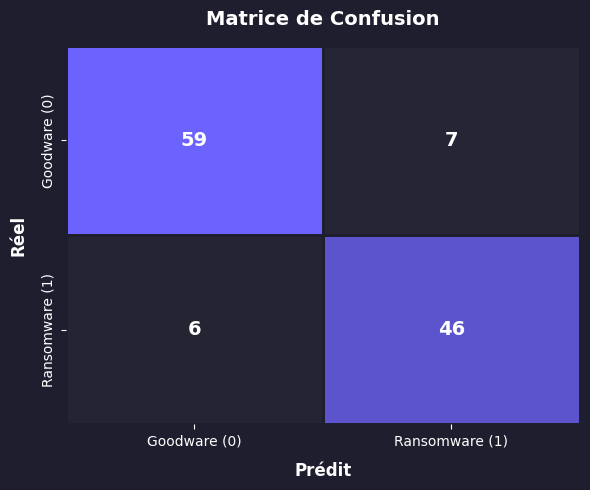

In [54]:
# ---- Graphique : Matrice de Confusion ----
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y_test, y_pred)
labels = ['Goodware (0)', 'Ransomware (1)']

fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor('#1e1e2e')
ax.set_facecolor('#1e1e2e')

# Palette de couleurs (dégradé sombre -> violet)
cmap = sns.dark_palette('#6C63FF', as_cmap=True)

sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=False,
            xticklabels=labels, yticklabels=labels,
            annot_kws={'size': 14, 'weight': 'bold', 'color': 'white'},
            linewidths=1, linecolor='#1e1e2e', ax=ax)

ax.set_xlabel('Prédit', color='white', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Réel', color='white', fontsize=12, fontweight='bold', labelpad=10)
ax.set_title('Matrice de Confusion', color='white', fontsize=14, fontweight='bold', pad=15)

ax.tick_params(colors='white', labelsize=10)
for sp in ax.spines.values(): sp.set_edgecolor('#444')

plt.tight_layout()
plt.show()


<div style="background:#2a2a3e;border-left:4px solid #FF6584;border-radius:5px;padding:13px 18px;margin:10px 0 8px 0;font-family:'Segoe UI',sans-serif;">
  <span style="display:inline-block;background:#FF6584;color:white;font-size:10px;font-weight:700;padding:1px 8px;border-radius:20px;letter-spacing:1px;margin-bottom:6px;">DATASET</span>
  <h3 style="margin:0;font-size:16px;color:#e0e0f0;font-weight:600;">Dataset synthetique — CTGAN</h3>
  <p style="margin:5px 0 0 0;font-size:12.5px;color:#aaaacc;">Entrainement sur les donnees synthetiques generees par CTGAN.</p>
</div>


In [55]:
cctgan=pd.read_csv("ctgan_synthetic.csv")
df_ctgan = pd.concat([df,cctgan])

X_ctgan = df_ctgan.drop("Label", axis=1)
y_ctgan = df_ctgan["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X_ctgan, y_ctgan, test_size=0.2, random_state=42
)
model = RandomForestClassifier()

model.fit(X_train, y_train)
y_pred = model.predict(X_test)


print("CTGAN Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))



CTGAN Accuracy: 0.9393939393939394
              precision    recall  f1-score   support

           0       0.92      0.96      0.94       100
           1       0.96      0.92      0.94        98

    accuracy                           0.94       198
   macro avg       0.94      0.94      0.94       198
weighted avg       0.94      0.94      0.94       198



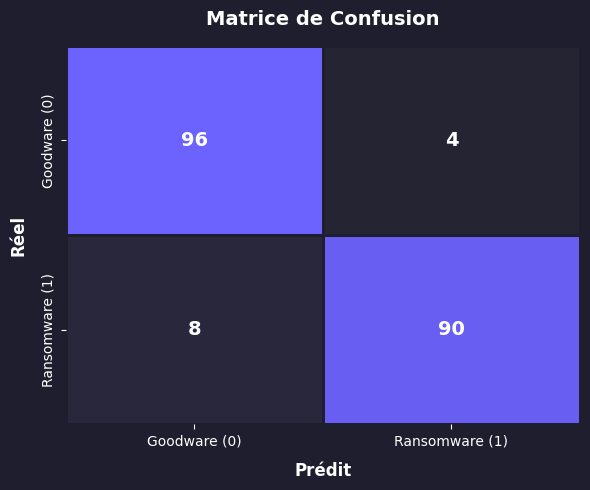

In [56]:
# ---- Graphique : Matrice de Confusion ----
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y_test, y_pred)
labels = ['Goodware (0)', 'Ransomware (1)']

fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor('#1e1e2e')
ax.set_facecolor('#1e1e2e')

# Palette de couleurs (dégradé sombre -> violet)
cmap = sns.dark_palette('#6C63FF', as_cmap=True)

sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=False,
            xticklabels=labels, yticklabels=labels,
            annot_kws={'size': 14, 'weight': 'bold', 'color': 'white'},
            linewidths=1, linecolor='#1e1e2e', ax=ax)

ax.set_xlabel('Prédit', color='white', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Réel', color='white', fontsize=12, fontweight='bold', labelpad=10)
ax.set_title('Matrice de Confusion', color='white', fontsize=14, fontweight='bold', pad=15)

ax.tick_params(colors='white', labelsize=10)
for sp in ax.spines.values(): sp.set_edgecolor('#444')

plt.tight_layout()
plt.show()


<div style="background:#2a2a3e;border-left:4px solid #FF6584;border-radius:5px;padding:13px 18px;margin:10px 0 8px 0;font-family:'Segoe UI',sans-serif;">
  <span style="display:inline-block;background:#FF6584;color:white;font-size:10px;font-weight:700;padding:1px 8px;border-radius:20px;letter-spacing:1px;margin-bottom:6px;">DATASET</span>
  <h3 style="margin:0;font-size:16px;color:#e0e0f0;font-weight:600;">Dataset synthetique — TVAE</h3>
  <p style="margin:5px 0 0 0;font-size:12.5px;color:#aaaacc;">Entrainement sur les donnees synthetiques generees par TVAE.</p>
</div>


In [57]:
ttvae=pd.read_csv("tvae_synthetic.csv")
df_ctgan = pd.concat([df,ttvae])

X_ctgan = df_ctgan.drop("Label", axis=1)
y_ctgan = df_ctgan["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X_ctgan, y_ctgan, test_size=0.2, random_state=42
)
model = RandomForestClassifier()

model.fit(X_train, y_train)
y_pred = model.predict(X_test)


print("CTGAN Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

CTGAN Accuracy: 0.9393939393939394
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       100
           1       0.95      0.93      0.94        98

    accuracy                           0.94       198
   macro avg       0.94      0.94      0.94       198
weighted avg       0.94      0.94      0.94       198



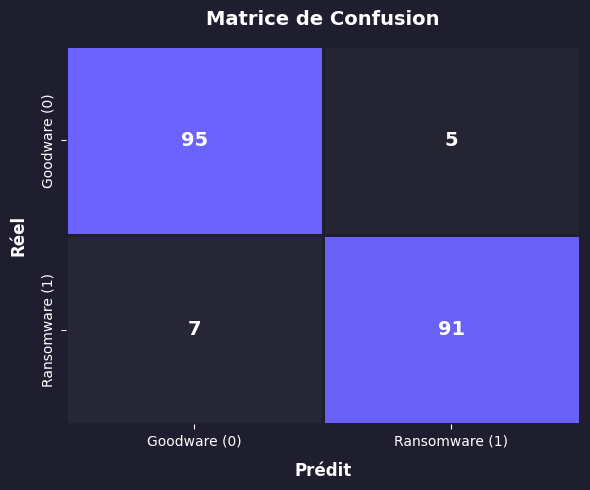

In [58]:
# ---- Graphique : Matrice de Confusion ----
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y_test, y_pred)
labels = ['Goodware (0)', 'Ransomware (1)']

fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor('#1e1e2e')
ax.set_facecolor('#1e1e2e')

# Palette de couleurs (dégradé sombre -> violet)
cmap = sns.dark_palette('#6C63FF', as_cmap=True)

sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=False,
            xticklabels=labels, yticklabels=labels,
            annot_kws={'size': 14, 'weight': 'bold', 'color': 'white'},
            linewidths=1, linecolor='#1e1e2e', ax=ax)

ax.set_xlabel('Prédit', color='white', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Réel', color='white', fontsize=12, fontweight='bold', labelpad=10)
ax.set_title('Matrice de Confusion', color='white', fontsize=14, fontweight='bold', pad=15)

ax.tick_params(colors='white', labelsize=10)
for sp in ax.spines.values(): sp.set_edgecolor('#444')

plt.tight_layout()
plt.show()


<div style="background:linear-gradient(90deg,#2a2a3e 0%,#1a1a30 100%);border-left:6px solid #6C63FF;border-radius:7px;padding:20px 24px;margin:20px 0 12px 0;font-family:'Segoe UI',sans-serif;">
  <h2 style="margin:0;font-size:22px;color:#e0e0f0;font-weight:800;letter-spacing:0.4px;">Support Vector Machine (SVM)</h2>
  <p style="margin:6px 0 0 0;font-size:13px;color:#b0b0cc;">Classifieur a vecteurs de support avec noyau RBF.</p>
</div>


<div style="background:#2a2a3e;border-left:4px solid #FF6584;border-radius:5px;padding:13px 18px;margin:10px 0 8px 0;font-family:'Segoe UI',sans-serif;">
  <span style="display:inline-block;background:#FF6584;color:white;font-size:10px;font-weight:700;padding:1px 8px;border-radius:20px;letter-spacing:1px;margin-bottom:6px;">DATASET</span>
  <h3 style="margin:0;font-size:16px;color:#e0e0f0;font-weight:600;">Dataset original</h3>
  <p style="margin:5px 0 0 0;font-size:12.5px;color:#aaaacc;">Entrainement et evaluation sur les donnees reelles.</p>
</div>


In [59]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
df=pd.read_csv("dataset_clean.csv")
X = df.drop("Label", axis=1)
y = df["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# normalisation
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# modèle SVM
model = SVC()

# entraînement
model.fit(X_train, y_train)

# prédiction
y_pred = model.predict(X_test)


print("ORIGINAL Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

ORIGINAL Accuracy: 0.788135593220339
              precision    recall  f1-score   support

           0       1.00      0.62      0.77        66
           1       0.68      1.00      0.81        52

    accuracy                           0.79       118
   macro avg       0.84      0.81      0.79       118
weighted avg       0.86      0.79      0.78       118



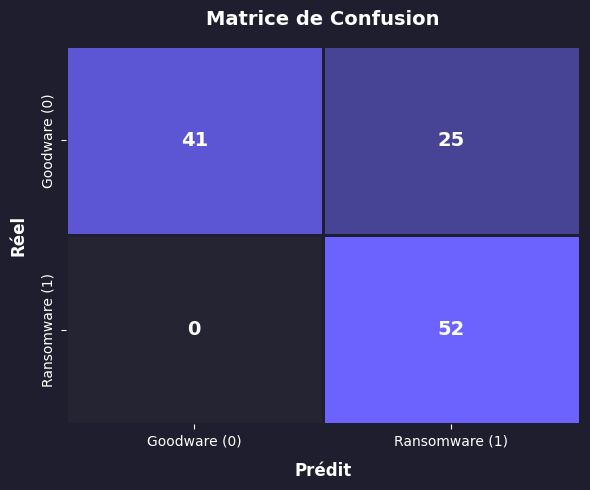

In [60]:
# ---- Graphique : Matrice de Confusion ----
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y_test, y_pred)
labels = ['Goodware (0)', 'Ransomware (1)']

fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor('#1e1e2e')
ax.set_facecolor('#1e1e2e')

# Palette de couleurs (dégradé sombre -> violet)
cmap = sns.dark_palette('#6C63FF', as_cmap=True)

sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=False,
            xticklabels=labels, yticklabels=labels,
            annot_kws={'size': 14, 'weight': 'bold', 'color': 'white'},
            linewidths=1, linecolor='#1e1e2e', ax=ax)

ax.set_xlabel('Prédit', color='white', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Réel', color='white', fontsize=12, fontweight='bold', labelpad=10)
ax.set_title('Matrice de Confusion', color='white', fontsize=14, fontweight='bold', pad=15)

ax.tick_params(colors='white', labelsize=10)
for sp in ax.spines.values(): sp.set_edgecolor('#444')

plt.tight_layout()
plt.show()


<div style="background:#2a2a3e;border-left:4px solid #FF6584;border-radius:5px;padding:13px 18px;margin:10px 0 8px 0;font-family:'Segoe UI',sans-serif;">
  <span style="display:inline-block;background:#FF6584;color:white;font-size:10px;font-weight:700;padding:1px 8px;border-radius:20px;letter-spacing:1px;margin-bottom:6px;">DATASET</span>
  <h3 style="margin:0;font-size:16px;color:#e0e0f0;font-weight:600;">Dataset synthetique — CTGAN</h3>
  <p style="margin:5px 0 0 0;font-size:12.5px;color:#aaaacc;">Entrainement sur les donnees synthetiques generees par CTGAN.</p>
</div>


In [61]:
cctgan=pd.read_csv("ctgan_synthetic.csv")
df_ctgan = pd.concat([df,cctgan])

X_ctgan = df_ctgan.drop("Label", axis=1)
y_ctgan = df_ctgan["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X_ctgan, y_ctgan, test_size=0.2, random_state=42
)


# normalisation
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = SVC()
# entraînement
model.fit(X_train, y_train)

# prédiction
y_pred = model.predict(X_test)


print("CTGAN Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

CTGAN Accuracy: 0.898989898989899
              precision    recall  f1-score   support

           0       1.00      0.80      0.89       100
           1       0.83      1.00      0.91        98

    accuracy                           0.90       198
   macro avg       0.92      0.90      0.90       198
weighted avg       0.92      0.90      0.90       198



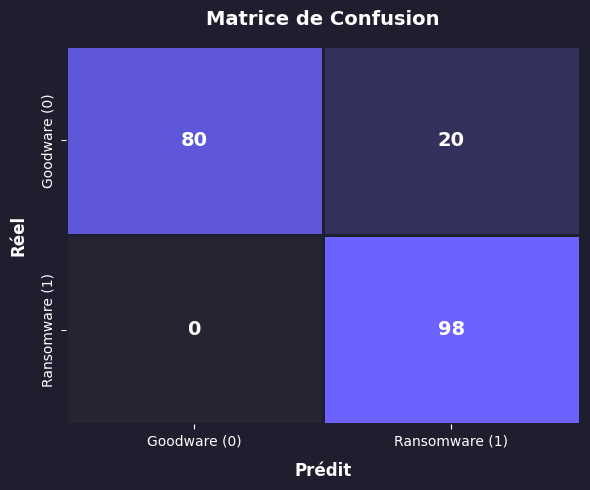

In [62]:
# ---- Graphique : Matrice de Confusion ----
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y_test, y_pred)
labels = ['Goodware (0)', 'Ransomware (1)']

fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor('#1e1e2e')
ax.set_facecolor('#1e1e2e')

# Palette de couleurs (dégradé sombre -> violet)
cmap = sns.dark_palette('#6C63FF', as_cmap=True)

sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=False,
            xticklabels=labels, yticklabels=labels,
            annot_kws={'size': 14, 'weight': 'bold', 'color': 'white'},
            linewidths=1, linecolor='#1e1e2e', ax=ax)

ax.set_xlabel('Prédit', color='white', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Réel', color='white', fontsize=12, fontweight='bold', labelpad=10)
ax.set_title('Matrice de Confusion', color='white', fontsize=14, fontweight='bold', pad=15)

ax.tick_params(colors='white', labelsize=10)
for sp in ax.spines.values(): sp.set_edgecolor('#444')

plt.tight_layout()
plt.show()


<div style="background:#2a2a3e;border-left:4px solid #FF6584;border-radius:5px;padding:13px 18px;margin:10px 0 8px 0;font-family:'Segoe UI',sans-serif;">
  <span style="display:inline-block;background:#FF6584;color:white;font-size:10px;font-weight:700;padding:1px 8px;border-radius:20px;letter-spacing:1px;margin-bottom:6px;">DATASET</span>
  <h3 style="margin:0;font-size:16px;color:#e0e0f0;font-weight:600;">Dataset synthetique — TVAE</h3>
  <p style="margin:5px 0 0 0;font-size:12.5px;color:#aaaacc;">Entrainement sur les donnees synthetiques generees par TVAE.</p>
</div>


In [63]:
ttvae=pd.read_csv("tvae_synthetic.csv")
df_ctgan = pd.concat([df,ttvae])

X_ctgan = df_ctgan.drop("Label", axis=1)
y_ctgan = df_ctgan["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X_ctgan, y_ctgan, test_size=0.2, random_state=42
)


# normalisation
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = SVC()
# entraînement
model.fit(X_train, y_train)

# prédiction
y_pred = model.predict(X_test)


print("CTGAN Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

CTGAN Accuracy: 0.8333333333333334
              precision    recall  f1-score   support

           0       0.94      0.72      0.81       100
           1       0.77      0.95      0.85        98

    accuracy                           0.83       198
   macro avg       0.85      0.83      0.83       198
weighted avg       0.85      0.83      0.83       198



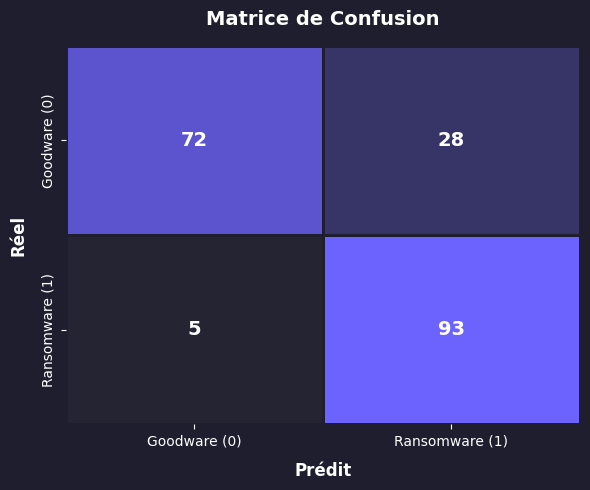

In [64]:
# ---- Graphique : Matrice de Confusion ----
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y_test, y_pred)
labels = ['Goodware (0)', 'Ransomware (1)']

fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor('#1e1e2e')
ax.set_facecolor('#1e1e2e')

# Palette de couleurs (dégradé sombre -> violet)
cmap = sns.dark_palette('#6C63FF', as_cmap=True)

sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=False,
            xticklabels=labels, yticklabels=labels,
            annot_kws={'size': 14, 'weight': 'bold', 'color': 'white'},
            linewidths=1, linecolor='#1e1e2e', ax=ax)

ax.set_xlabel('Prédit', color='white', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Réel', color='white', fontsize=12, fontweight='bold', labelpad=10)
ax.set_title('Matrice de Confusion', color='white', fontsize=14, fontweight='bold', pad=15)

ax.tick_params(colors='white', labelsize=10)
for sp in ax.spines.values(): sp.set_edgecolor('#444')

plt.tight_layout()
plt.show()


<div style="background:linear-gradient(90deg,#2a2a3e 0%,#1a1a30 100%);border-left:6px solid #6C63FF;border-radius:7px;padding:20px 24px;margin:20px 0 12px 0;font-family:'Segoe UI',sans-serif;">
  <h2 style="margin:0;font-size:22px;color:#e0e0f0;font-weight:800;letter-spacing:0.4px;">Regression Logistique</h2>
  <p style="margin:6px 0 0 0;font-size:13px;color:#b0b0cc;">Modele lineaire de reference — simple et interpretable.</p>
</div>


<div style="background:#2a2a3e;border-left:4px solid #FF6584;border-radius:5px;padding:13px 18px;margin:10px 0 8px 0;font-family:'Segoe UI',sans-serif;">
  <span style="display:inline-block;background:#FF6584;color:white;font-size:10px;font-weight:700;padding:1px 8px;border-radius:20px;letter-spacing:1px;margin-bottom:6px;">DATASET</span>
  <h3 style="margin:0;font-size:16px;color:#e0e0f0;font-weight:600;">Dataset original</h3>
  <p style="margin:5px 0 0 0;font-size:12.5px;color:#aaaacc;">Entrainement et evaluation sur les donnees reelles.</p>
</div>


In [65]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
df=pd.read_csv("dataset_clean.csv")
X = df.drop("Label", axis=1)
y = df["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# normalisation
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# modèle SVM
model = LogisticRegression()

# entraînement
model.fit(X_train, y_train)

# prédiction
y_pred = model.predict(X_test)


print("ORIGINAL Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

ORIGINAL Accuracy: 0.8728813559322034
              precision    recall  f1-score   support

           0       0.96      0.80      0.88        66
           1       0.79      0.96      0.87        52

    accuracy                           0.87       118
   macro avg       0.88      0.88      0.87       118
weighted avg       0.89      0.87      0.87       118



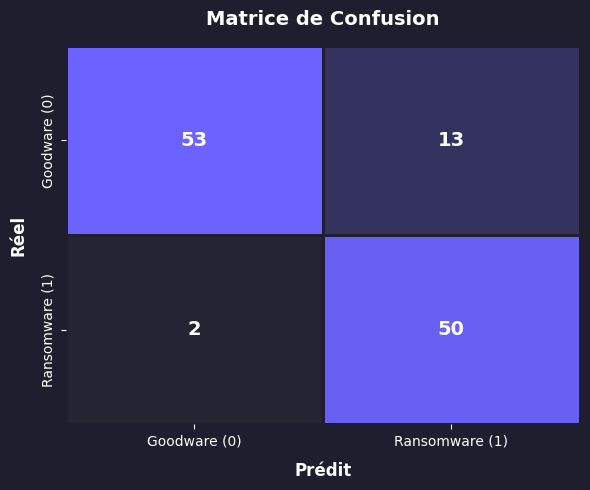

In [66]:
# ---- Graphique : Matrice de Confusion ----
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y_test, y_pred)
labels = ['Goodware (0)', 'Ransomware (1)']

fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor('#1e1e2e')
ax.set_facecolor('#1e1e2e')

# Palette de couleurs (dégradé sombre -> violet)
cmap = sns.dark_palette('#6C63FF', as_cmap=True)

sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=False,
            xticklabels=labels, yticklabels=labels,
            annot_kws={'size': 14, 'weight': 'bold', 'color': 'white'},
            linewidths=1, linecolor='#1e1e2e', ax=ax)

ax.set_xlabel('Prédit', color='white', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Réel', color='white', fontsize=12, fontweight='bold', labelpad=10)
ax.set_title('Matrice de Confusion', color='white', fontsize=14, fontweight='bold', pad=15)

ax.tick_params(colors='white', labelsize=10)
for sp in ax.spines.values(): sp.set_edgecolor('#444')

plt.tight_layout()
plt.show()


<div style="background:#2a2a3e;border-left:4px solid #FF6584;border-radius:5px;padding:13px 18px;margin:10px 0 8px 0;font-family:'Segoe UI',sans-serif;">
  <span style="display:inline-block;background:#FF6584;color:white;font-size:10px;font-weight:700;padding:1px 8px;border-radius:20px;letter-spacing:1px;margin-bottom:6px;">DATASET</span>
  <h3 style="margin:0;font-size:16px;color:#e0e0f0;font-weight:600;">Dataset synthetique — CTGAN</h3>
  <p style="margin:5px 0 0 0;font-size:12.5px;color:#aaaacc;">Entrainement sur les donnees synthetiques generees par CTGAN.</p>
</div>


In [67]:
cctgan=pd.read_csv("ctgan_synthetic.csv")
df_ctgan = pd.concat([df,cctgan])

X_ctgan = df_ctgan.drop("Label", axis=1)
y_ctgan = df_ctgan["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X_ctgan, y_ctgan, test_size=0.2, random_state=42
)

# normalisation
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# normalisation
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression()
# entraînement
model.fit(X_train, y_train)

# prédiction
y_pred = model.predict(X_test)


print("CTGAN Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

CTGAN Accuracy: 0.9242424242424242
              precision    recall  f1-score   support

           0       0.98      0.87      0.92       100
           1       0.88      0.98      0.93        98

    accuracy                           0.92       198
   macro avg       0.93      0.92      0.92       198
weighted avg       0.93      0.92      0.92       198



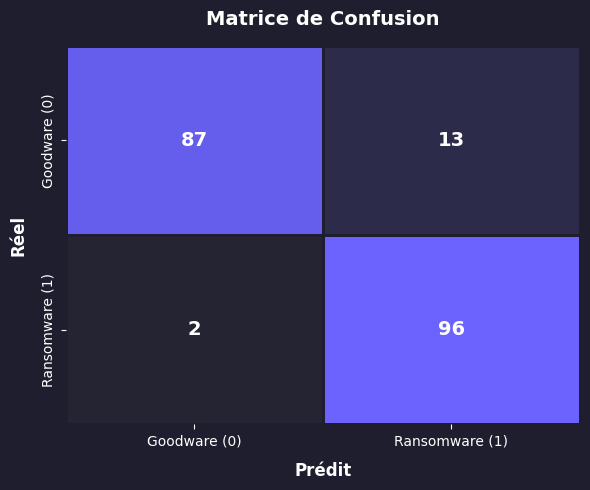

In [68]:
# ---- Graphique : Matrice de Confusion ----
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y_test, y_pred)
labels = ['Goodware (0)', 'Ransomware (1)']

fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor('#1e1e2e')
ax.set_facecolor('#1e1e2e')

# Palette de couleurs (dégradé sombre -> violet)
cmap = sns.dark_palette('#6C63FF', as_cmap=True)

sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=False,
            xticklabels=labels, yticklabels=labels,
            annot_kws={'size': 14, 'weight': 'bold', 'color': 'white'},
            linewidths=1, linecolor='#1e1e2e', ax=ax)

ax.set_xlabel('Prédit', color='white', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Réel', color='white', fontsize=12, fontweight='bold', labelpad=10)
ax.set_title('Matrice de Confusion', color='white', fontsize=14, fontweight='bold', pad=15)

ax.tick_params(colors='white', labelsize=10)
for sp in ax.spines.values(): sp.set_edgecolor('#444')

plt.tight_layout()
plt.show()


<div style="background:#2a2a3e;border-left:4px solid #FF6584;border-radius:5px;padding:13px 18px;margin:10px 0 8px 0;font-family:'Segoe UI',sans-serif;">
  <span style="display:inline-block;background:#FF6584;color:white;font-size:10px;font-weight:700;padding:1px 8px;border-radius:20px;letter-spacing:1px;margin-bottom:6px;">DATASET</span>
  <h3 style="margin:0;font-size:16px;color:#e0e0f0;font-weight:600;">Dataset synthetique — TVAE</h3>
  <p style="margin:5px 0 0 0;font-size:12.5px;color:#aaaacc;">Entrainement sur les donnees synthetiques generees par TVAE.</p>
</div>


In [69]:
ttvae=pd.read_csv("tvae_synthetic.csv")
df_ctgan = pd.concat([df,ttvae])

X_ctgan = df_ctgan.drop("Label", axis=1)
y_ctgan = df_ctgan["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X_ctgan, y_ctgan, test_size=0.2, random_state=42
)


# normalisation
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression()
# entraînement
model.fit(X_train, y_train)

# prédiction
y_pred = model.predict(X_test)


print("CTGAN Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

CTGAN Accuracy: 0.8939393939393939
              precision    recall  f1-score   support

           0       0.95      0.83      0.89       100
           1       0.85      0.96      0.90        98

    accuracy                           0.89       198
   macro avg       0.90      0.89      0.89       198
weighted avg       0.90      0.89      0.89       198



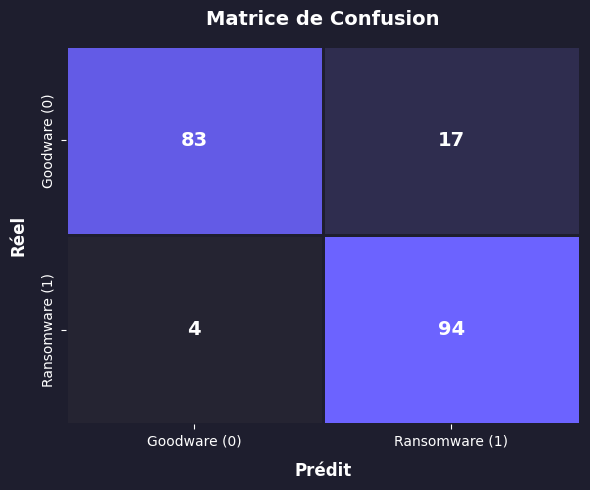

In [70]:
# ---- Graphique : Matrice de Confusion ----
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y_test, y_pred)
labels = ['Goodware (0)', 'Ransomware (1)']

fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor('#1e1e2e')
ax.set_facecolor('#1e1e2e')

# Palette de couleurs (dégradé sombre -> violet)
cmap = sns.dark_palette('#6C63FF', as_cmap=True)

sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=False,
            xticklabels=labels, yticklabels=labels,
            annot_kws={'size': 14, 'weight': 'bold', 'color': 'white'},
            linewidths=1, linecolor='#1e1e2e', ax=ax)

ax.set_xlabel('Prédit', color='white', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Réel', color='white', fontsize=12, fontweight='bold', labelpad=10)
ax.set_title('Matrice de Confusion', color='white', fontsize=14, fontweight='bold', pad=15)

ax.tick_params(colors='white', labelsize=10)
for sp in ax.spines.values(): sp.set_edgecolor('#444')

plt.tight_layout()
plt.show()


<div style="background:linear-gradient(90deg,#2a2a3e 0%,#1a1a30 100%);border-left:6px solid #6C63FF;border-radius:7px;padding:20px 24px;margin:20px 0 12px 0;font-family:'Segoe UI',sans-serif;">
  <h2 style="margin:0;font-size:22px;color:#e0e0f0;font-weight:800;letter-spacing:0.4px;">Naive Bayes</h2>
  <p style="margin:6px 0 0 0;font-size:13px;color:#b0b0cc;">Classifieur probabiliste base sur le theoreme de Bayes.</p>
</div>


<div style="background:#2a2a3e;border-left:4px solid #FF6584;border-radius:5px;padding:13px 18px;margin:10px 0 8px 0;font-family:'Segoe UI',sans-serif;">
  <span style="display:inline-block;background:#FF6584;color:white;font-size:10px;font-weight:700;padding:1px 8px;border-radius:20px;letter-spacing:1px;margin-bottom:6px;">DATASET</span>
  <h3 style="margin:0;font-size:16px;color:#e0e0f0;font-weight:600;">Dataset original</h3>
  <p style="margin:5px 0 0 0;font-size:12.5px;color:#aaaacc;">Entrainement et evaluation sur les donnees reelles.</p>
</div>


In [71]:
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
df=pd.read_csv("dataset_clean.csv")
X = df.drop("Label", axis=1)
y = df["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# normalisation
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# modèle SVM
model = GaussianNB()

# entraînement
model.fit(X_train, y_train)

# prédiction
y_pred = model.predict(X_test)


print("ORIGINAL Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

ORIGINAL Accuracy: 0.8135593220338984
              precision    recall  f1-score   support

           0       1.00      0.67      0.80        66
           1       0.70      1.00      0.83        52

    accuracy                           0.81       118
   macro avg       0.85      0.83      0.81       118
weighted avg       0.87      0.81      0.81       118



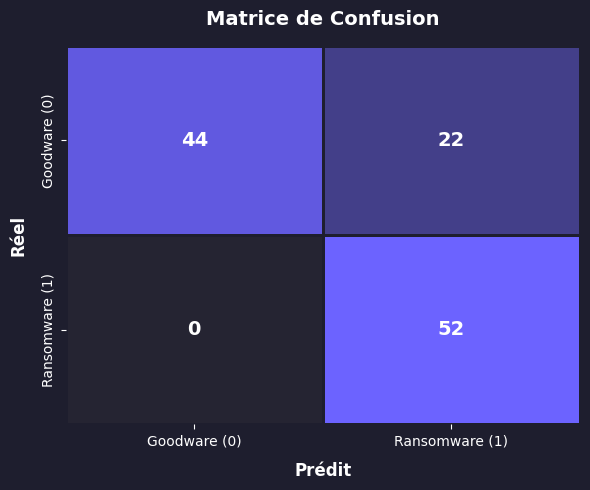

In [72]:
# ---- Graphique : Matrice de Confusion ----
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y_test, y_pred)
labels = ['Goodware (0)', 'Ransomware (1)']

fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor('#1e1e2e')
ax.set_facecolor('#1e1e2e')

# Palette de couleurs (dégradé sombre -> violet)
cmap = sns.dark_palette('#6C63FF', as_cmap=True)

sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=False,
            xticklabels=labels, yticklabels=labels,
            annot_kws={'size': 14, 'weight': 'bold', 'color': 'white'},
            linewidths=1, linecolor='#1e1e2e', ax=ax)

ax.set_xlabel('Prédit', color='white', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Réel', color='white', fontsize=12, fontweight='bold', labelpad=10)
ax.set_title('Matrice de Confusion', color='white', fontsize=14, fontweight='bold', pad=15)

ax.tick_params(colors='white', labelsize=10)
for sp in ax.spines.values(): sp.set_edgecolor('#444')

plt.tight_layout()
plt.show()


<div style="background:#2a2a3e;border-left:4px solid #FF6584;border-radius:5px;padding:13px 18px;margin:10px 0 8px 0;font-family:'Segoe UI',sans-serif;">
  <span style="display:inline-block;background:#FF6584;color:white;font-size:10px;font-weight:700;padding:1px 8px;border-radius:20px;letter-spacing:1px;margin-bottom:6px;">DATASET</span>
  <h3 style="margin:0;font-size:16px;color:#e0e0f0;font-weight:600;">Dataset synthetique — CTGAN</h3>
  <p style="margin:5px 0 0 0;font-size:12.5px;color:#aaaacc;">Entrainement sur les donnees synthetiques generees par CTGAN.</p>
</div>


In [73]:
cctgan=pd.read_csv("ctgan_synthetic.csv")
df_ctgan = pd.concat([df,cctgan])

X_ctgan = df_ctgan.drop("Label", axis=1)
y_ctgan = df_ctgan["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X_ctgan, y_ctgan, test_size=0.2, random_state=42
)

# normalisation
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# normalisation
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = GaussianNB()
# entraînement
model.fit(X_train, y_train)

# prédiction
y_pred = model.predict(X_test)


print("CTGAN Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

CTGAN Accuracy: 0.8787878787878788
              precision    recall  f1-score   support

           0       0.95      0.80      0.87       100
           1       0.82      0.96      0.89        98

    accuracy                           0.88       198
   macro avg       0.89      0.88      0.88       198
weighted avg       0.89      0.88      0.88       198



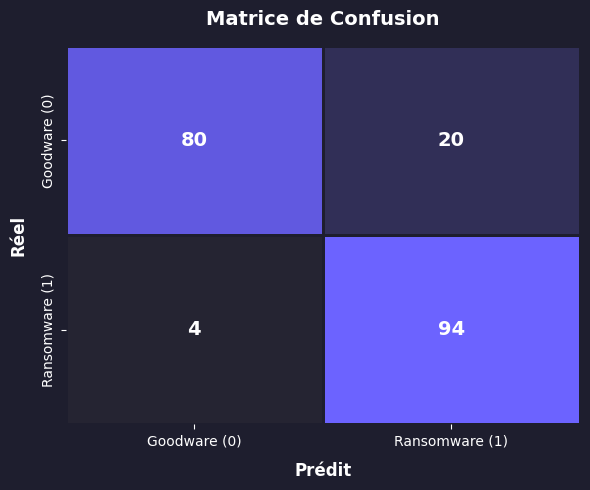

In [74]:
# ---- Graphique : Matrice de Confusion ----
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y_test, y_pred)
labels = ['Goodware (0)', 'Ransomware (1)']

fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor('#1e1e2e')
ax.set_facecolor('#1e1e2e')

# Palette de couleurs (dégradé sombre -> violet)
cmap = sns.dark_palette('#6C63FF', as_cmap=True)

sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=False,
            xticklabels=labels, yticklabels=labels,
            annot_kws={'size': 14, 'weight': 'bold', 'color': 'white'},
            linewidths=1, linecolor='#1e1e2e', ax=ax)

ax.set_xlabel('Prédit', color='white', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Réel', color='white', fontsize=12, fontweight='bold', labelpad=10)
ax.set_title('Matrice de Confusion', color='white', fontsize=14, fontweight='bold', pad=15)

ax.tick_params(colors='white', labelsize=10)
for sp in ax.spines.values(): sp.set_edgecolor('#444')

plt.tight_layout()
plt.show()


<div style="background:#2a2a3e;border-left:4px solid #FF6584;border-radius:5px;padding:13px 18px;margin:10px 0 8px 0;font-family:'Segoe UI',sans-serif;">
  <span style="display:inline-block;background:#FF6584;color:white;font-size:10px;font-weight:700;padding:1px 8px;border-radius:20px;letter-spacing:1px;margin-bottom:6px;">DATASET</span>
  <h3 style="margin:0;font-size:16px;color:#e0e0f0;font-weight:600;">Dataset synthetique — TVAE</h3>
  <p style="margin:5px 0 0 0;font-size:12.5px;color:#aaaacc;">Entrainement sur les donnees synthetiques generees par TVAE.</p>
</div>


In [75]:
ttvae=pd.read_csv("tvae_synthetic.csv")
df_ctgan = pd.concat([df,ttvae])

X_ctgan = df_ctgan.drop("Label", axis=1)
y_ctgan = df_ctgan["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X_ctgan, y_ctgan, test_size=0.2, random_state=42
)


# normalisation
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = GaussianNB()
# entraînement
model.fit(X_train, y_train)

# prédiction
y_pred = model.predict(X_test)


print("CTGAN Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

CTGAN Accuracy: 0.8232323232323232
              precision    recall  f1-score   support

           0       0.96      0.68      0.80       100
           1       0.75      0.97      0.84        98

    accuracy                           0.82       198
   macro avg       0.85      0.82      0.82       198
weighted avg       0.85      0.82      0.82       198



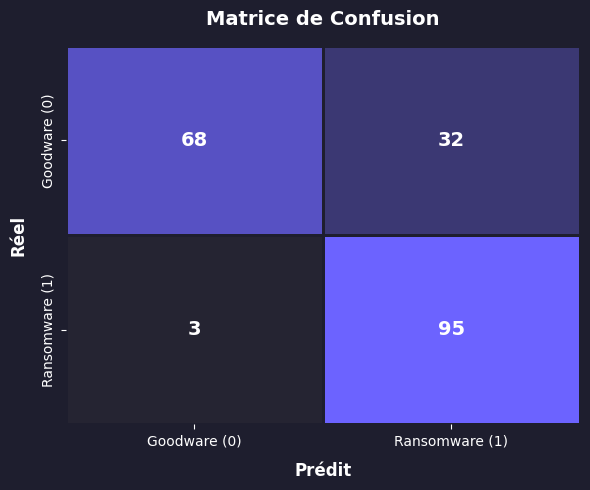

In [76]:
# ---- Graphique : Matrice de Confusion ----
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y_test, y_pred)
labels = ['Goodware (0)', 'Ransomware (1)']

fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor('#1e1e2e')
ax.set_facecolor('#1e1e2e')

# Palette de couleurs (dégradé sombre -> violet)
cmap = sns.dark_palette('#6C63FF', as_cmap=True)

sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=False,
            xticklabels=labels, yticklabels=labels,
            annot_kws={'size': 14, 'weight': 'bold', 'color': 'white'},
            linewidths=1, linecolor='#1e1e2e', ax=ax)

ax.set_xlabel('Prédit', color='white', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Réel', color='white', fontsize=12, fontweight='bold', labelpad=10)
ax.set_title('Matrice de Confusion', color='white', fontsize=14, fontweight='bold', pad=15)

ax.tick_params(colors='white', labelsize=10)
for sp in ax.spines.values(): sp.set_edgecolor('#444')

plt.tight_layout()
plt.show()
